In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(27)

# Data Generation

In [2]:
K = 3

n_samples = [1000, 400, 600]
real_means = [0, 10,20]
real_variances = [1.2, 1.8, 1.6]

data = []

for k in range(K):
    x = np.random.normal(real_means[k], np.sqrt(real_variances[k]), n_samples[k]) # we have generated a data point
    # with real mean and  real variance following normal distribution
    data.extend(x) # adding a data point to x to make a list # append gareko vaye list vitra list banauna
    #print(x)

data = np.array(data)# changing list to an array
np.random.shuffle(data) # changing the position of data points to random positions.

print("Dataset Shape: ", data.shape)

Dataset Shape:  (2000,)


# Random Initialization

In [3]:
# Parameters that we have to learn weights, means, variance
# variance > 0
# mean any number
# weights = Sum equal to one
variances = np.random.random_sample(K)
means = np.random.choice(data,K)
weights = np.array([1/K]*3)

print(weights, means, variances)

[0.33333333 0.33333333 0.33333333] [-0.93384518 18.64080283  1.87796424] [0.83197951 0.11303372 0.11116073]


Gaussian Distribution

$ pdf(x) = \frac{e^{\frac{-(x - \mu)^2}{2 \sigma ^ 2}}}{\sigma \sqrt{2 \pi}} $

In [4]:
def pdf(data, mean, variance):
    pd = np.exp((-np.square(data-mean))/(2*variance))/(np.sqrt(variance)*np.sqrt(2 * np.pi))
    return pd
    

In [5]:
#rik = (pdf(weights[i],means[i], variance[i]) * weights[i])/(np.sum(pdf(wieghts[i],means[i], variance)))


Reference: 

http://bjlkeng.github.io/posts/the-expectation-maximization-algorithm/

https://courses.cs.washington.edu/courses/cse312/11wi/slides/12em.pdf


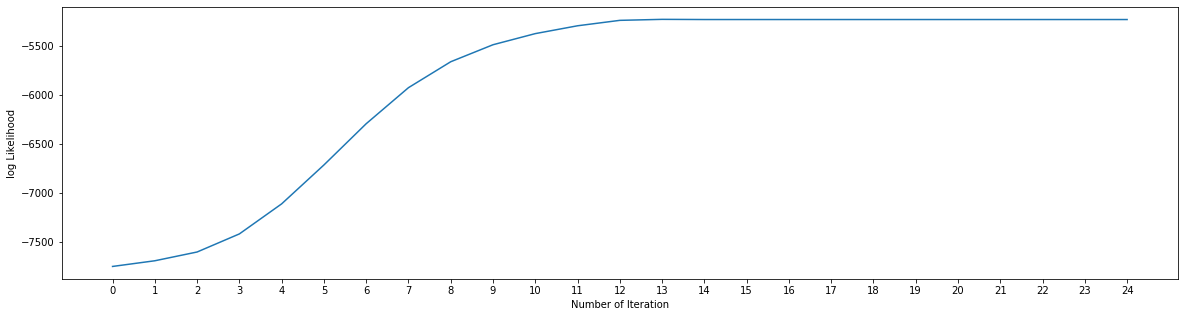

In [6]:
max_iter = 25

total_performance = []

for step in range(max_iter):

    # E-Steps
    likelihood = []
    for k in range(K):
        r = pdf(data, means[k],variances[k])
        likelihood.append(r)
       
    # M-Steps   
    b = []
    for k in range(K):
        b.append((likelihood[k]*weights[k])/(np.sum([likelihood[i]*weights[i] for i in range(K)], axis = 0)))
        
        weights[k] = np.mean(b[k])
        
        means[k] = np.sum(b[k] * data)/np.sum(b[k])
        
        variances[k] = np.sum(b[k] * np.square(data -means[k])) / np.sum(b[k])
        
  
    performance = 0
    #for j in range(K):
       # d = pdf(data, mean[i],)

    for i in range(len(data)):
        prob = 0
        for k in range(K):
            prob += weights[k] * pdf(data[i], means[k], np.sqrt(variances[k]))
        performance += np.log(prob)
  
    total_performance.append(performance)

plt.figure(figsize=(20, 5))
plt.plot(total_performance)
# plt.title("p(x|theta_i) p(theta_i|theta_-i, alpha) Vs Number of Iteration")
plt.xlabel("Number of Iteration")
plt.ylabel("log Likelihood")
plt.xticks([i for i in range(max_iter)])

plt.show()



In [7]:
np.set_printoptions(precision=3, suppress=True)
print("Predicted Weights:", weights)
print("Predicted Means:", means)
print("Predicted Variances:", variances)

Predicted Weights: [0.2 0.3 0.5]
Predicted Means: [10.036 20.053 -0.008]
Predicted Variances: [1.551 1.449 1.267]


In [8]:
print("Real Weights:", [i/sum(n_samples) for i in n_samples])
print("Real Means:", real_means)
print("Read Variances:", real_variances)

Real Weights: [0.5, 0.2, 0.3]
Real Means: [0, 10, 20]
Read Variances: [1.2, 1.8, 1.6]


# Using Sklearn

In [17]:
from sklearn import mixture

In [18]:
gmm = mixture.GaussianMixture(n_components = 3)
gmm.fit(data.reshape(-1,1))

GaussianMixture(covariance_type='full', init_params='kmeans', max_iter=100,
                means_init=None, n_components=3, n_init=1, precisions_init=None,
                random_state=None, reg_covar=1e-06, tol=0.001, verbose=0,
                verbose_interval=10, warm_start=False, weights_init=None)

In [19]:
gmm.weights_

array([0.50000002, 0.29999851, 0.20000147])

In [20]:
gmm.means_

array([[-8.21711205e-03],
       [ 2.00530676e+01],
       [ 1.00356078e+01]])

In [22]:
gmm.covariances_

array([[[1.26710952]],

       [[1.44927621]],

       [[1.55086111]]])